In [17]:
import pandas as pd

In [18]:
data = pd.read_csv('/content/data.csv')

In [19]:
genre_data = pd.read_csv('/content/data_by_genres.csv')

In [20]:
year_data = pd.read_csv('/content/data_by_year.csv')

In [21]:
artist_data = pd.read_csv('/content/data_by_artist.csv')

## Phase Objective: Perform Exploratory Data Analysis

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

### 1. Visualize the distribution of tracks across different decades using a count plot

/tmp/ipykernel_372/229825554.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='decade', data=data_cleaned, palette='viridis', order=sorted(data_cleaned['decade'].unique()))


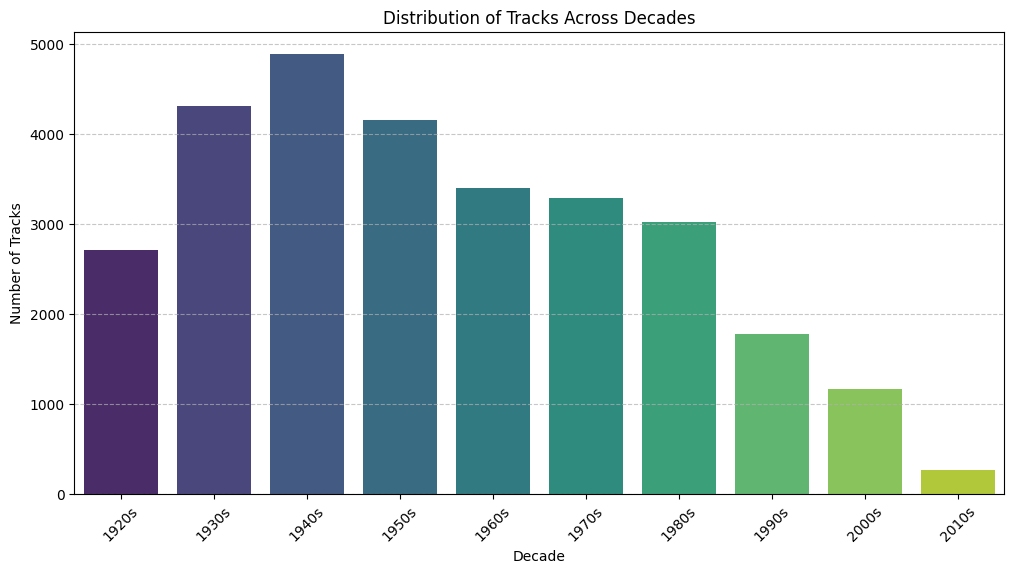

In [23]:
plt.figure(figsize=(12, 6))
sns.countplot(x='decade', data=data_cleaned, palette='viridis', order=sorted(data_cleaned['decade'].unique()))
plt.title('Distribution of Tracks Across Decades')
plt.xlabel('Decade')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 2. Plot the trends of various sound features over decades

In [24]:
sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']
fig = px.line(year_data, x='year', y=sound_features, title='Trend of various sound features over decades')
fig.show()

### 3. Plot the trend of loudness over decades

In [25]:
fig = px.line(year_data, x='year', y='loudness', title='Trend of loudness over decades')
fig.show()

### 4. Identify the top 10 genres based on popularity and plot trends of sound features

In [26]:
# Sort genres by popularity and get the top 10
top10_genres_popularity = genre_data.sort_values(by='popularity', ascending=False).head(10)

# Select the sound features to plot
sound_features_genres = ['valence', 'energy', 'danceability', 'acousticness']

# Plotting the grouped bar chart
fig = px.bar(top10_genres_popularity,
             x='genres',
             y=sound_features_genres,
             barmode='group',
             title='Trend of various sound features over top 10 genres by Popularity',
             labels={'value': 'Feature Value', 'variable': 'Sound Feature'})
fig.update_layout(xaxis_title='Genre', yaxis_title='Mean Value')
fig.show()

### 5. Generate a word cloud of the genres present in the dataset

In [27]:
# Prepare the text for the word cloud
comment_words_genre = ''
stopwords_genre = set(STOPWORDS)

# Iterate through the 'genres' column and add words to comment_words_genre
for val in genre_data['genres'].astype(str):
    val = str(val).lower() # Convert to string and lowercase
    tokens = val.split() # Split into words
    for i in range(len(tokens)): # Add each token to the comment_words_genre
        comment_words_genre = comment_words_genre + tokens[i] + ' '

wordcloud_genre = WordCloud(width=800, height=800,
                        background_color='white',
                        stopwords=stopwords_genre,
                        max_words=40,
                        min_font_size=10).generate(comment_words_genre)

### 6. Plot the word cloud of the genres

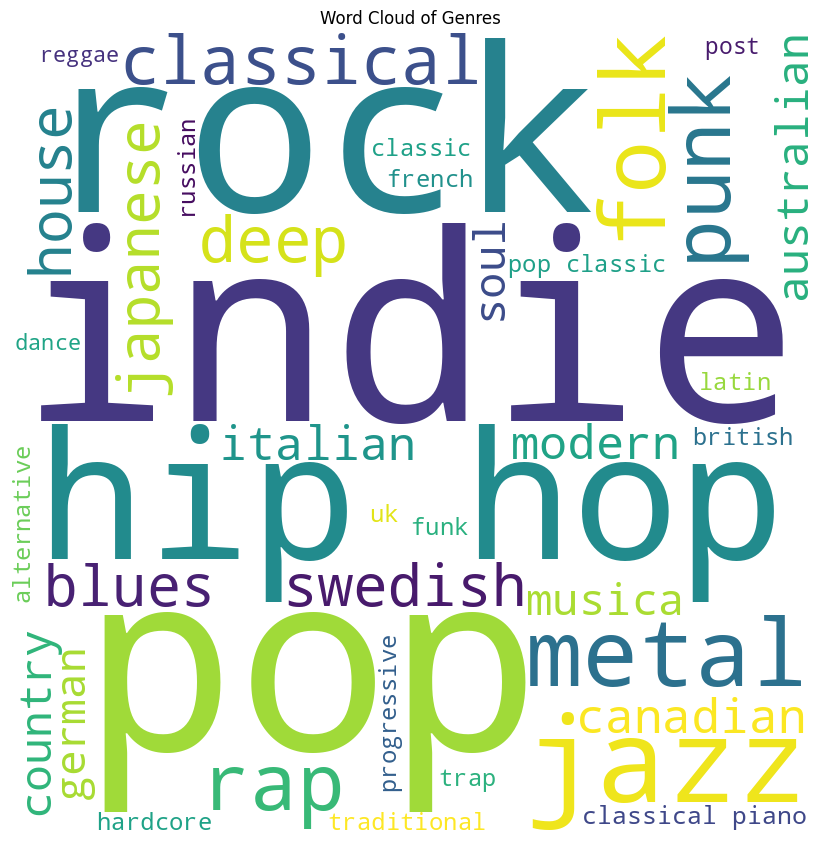

In [28]:
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud_genre)
plt.axis("off")
plt.tight_layout(pad=0)
plt.title('Word Cloud of Genres')
plt.show()

### 7. Generate a word cloud of the artists present in the dataset

In [ ]:
# Prepare the text for the word cloud for artists
comment_words_artist = ''
stopwords_artist = set(STOPWORDS)

# Iterate through the 'artists' column in the 'data' DataFrame and add words to comment_words_artist
# Assuming 'artists' column contains string representations of lists (e.g., "['Artist Name']")
for val in data['artists'].astype(str):
    # Remove brackets and quotes, then split by comma and space
    val = val.replace("['", "").replace("']", "").replace("'", "").replace('"', "").lower()
    tokens = val.replace(", ", " ").split() # Replace ', ' with space then split
    for i in range(len(tokens)):
        comment_words_artist = comment_words_artist + tokens[i] + ' '

wordcloud_artist = WordCloud(width=800, height=800,
                        background_color='white',
                        stopwords=stopwords_artist,
                        min_word_length=3,
                        max_words=40,
                        min_font_size=10).generate(comment_words_artist)

### 8. Plot the word cloud of the artists

In [ ]:
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud_artist)
plt.axis("off")
plt.tight_layout(pad=0)
plt.title('Word Cloud of Artists')
plt.show()

### 9. Identify the top 10 artists with the most songs produced

In [ ]:
# The 'artist_data' DataFrame already contains 'count' for each artist
top10_most_song_produced_artists = artist_data.sort_values(by='count', ascending=False).head(10)
display(top10_most_song_produced_artists[['count','artists']])

### 10. Identify the top 10 artists with the highest popularity score

In [ ]:
# The 'artist_data' DataFrame already contains 'popularity' for each artist
top10_popular_artists = artist_data.sort_values(by='popularity', ascending=False).head(10)
display(top10_popular_artists[['popularity','artists']])

### 11. Conclusion about our Data

This concludes the exploratory data analysis. We have visualized various aspects of the Spotify dataset, including:

*   **Decade Distribution**: How the number of tracks is distributed across different decades.
*   **Sound Feature Trends**: How acousticness, danceability, energy, instrumentalness, liveness, valence, and loudness have changed over the years.
*   **Top Genres Analysis**: Identified the most popular genres and their characteristic sound features.
*   **Word Clouds**: Visualized the most frequent genres and artists using word clouds.
*   **Top Artists**: Identified artists with the most songs and highest popularity.

These insights provide a foundational understanding of the dataset, which can be further explored for more in-depth analysis or used for building predictive models.